In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)
from imblearn.over_sampling import SMOTE

print("All imports successful ✅")

All imports successful ✅


In [5]:
df = pd.read_csv('../data/creditcard.csv')

print(f"Dataset shape  : {df.shape}")
print(f"Fraud cases    : {df['Class'].sum():,}")
print(f"Legit cases    : {(df['Class']==0).sum():,}")
print(f"Fraud rate     : {df['Class'].mean()*100:.4f}%")

Dataset shape  : (284807, 31)
Fraud cases    : 492
Legit cases    : 284,315
Fraud rate     : 0.1727%


In [18]:
# X = everything the model uses to learn (features)
# y = what we're trying to predict (0=legit, 1=fraud)

X = df.drop(columns=['Class'])
y = df['Class']

print(f"Features (X) shape : {X.shape}")
print(f"Target (y) shape   : {y.shape}")
print(f"\nFeature columns:\n{list(X.columns)}")

Features (X) shape : (284807, 30)
Target (y) shape   : (284807,)

Feature columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Explicit copies prevent SettingWithCopyWarning
X_train = X_train.copy()
X_test  = X_test.copy()

In [27]:
scaler = StandardScaler()
X_train[['Amount', 'Time']] = scaler.fit_transform(X_train[['Amount', 'Time']])
X_test[['Amount', 'Time']]  = scaler.transform(X_test[['Amount', 'Time']])

print("Scaling complete ✅")
print(f"  Train Amount mean: {X_train['Amount'].mean():.6f}")
print(f"  Train Time mean:   {X_train['Time'].mean():.6f}")
print(f"  Test Amount mean:  {X_test['Amount'].mean():.6f}")
print(f"  Test Time mean:    {X_test['Time'].mean():.6f}")

Scaling complete ✅
  Train Amount mean: 0.000000
  Train Time mean:   -0.000000
  Test Amount mean:  0.003456
  Test Time mean:    -0.007500


In [28]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"\nSMOTE applied ✅")
print(f"  Before: {pd.Series(y_train).value_counts().to_dict()}")
print(f"  After:  {pd.Series(y_train_res).value_counts().to_dict()}")


SMOTE applied ✅
  Before: {0: 227451, 1: 394}
  After:  {0: 227451, 1: 227451}


In [29]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
model.fit(X_train_res, y_train_res)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [30]:
y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]
print("Predictions complete ✅")

# ─── 8. Evaluation ────────────────────────────────────────
print(f"\nROC-AUC: {roc_auc_score(y_test, y_pred_prob):.4f}")
print(classification_report(y_test, y_pred))

# Save artifacts
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(model, 'model.joblib')
print("Saved: scaler.joblib, model.joblib")

Predictions complete ✅

ROC-AUC: 0.9731
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.84      0.84        98

    accuracy                           1.00     56962
   macro avg       0.92      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962

Saved: scaler.joblib, model.joblib


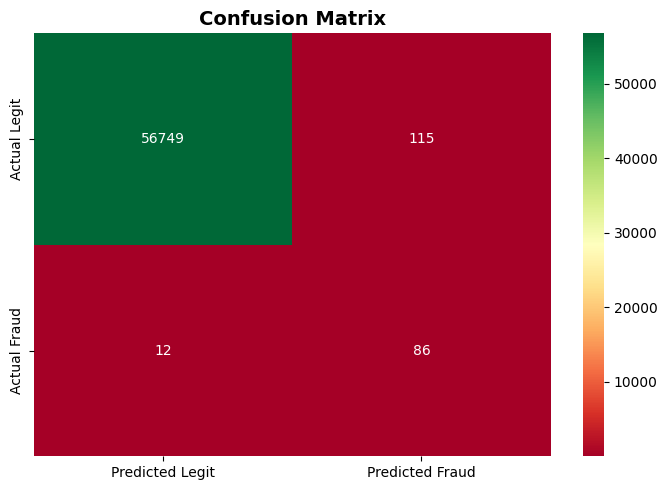


True Negatives  (correctly caught legit) : 56,749
False Positives (legit flagged as fraud)  : 115
False Negatives (fraud we MISSED)         : 12
True Positives  (fraud correctly caught)  : 86

Fraud Recall : 87.76% of frauds caught


In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d',
            cmap='RdYlGn',
            xticklabels=['Predicted Legit', 'Predicted Fraud'],
            yticklabels=['Actual Legit', 'Actual Fraud'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/confusion_matrix.png', dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives  (correctly caught legit) : {tn:,}")
print(f"False Positives (legit flagged as fraud)  : {fp:,}")
print(f"False Negatives (fraud we MISSED)         : {fn:,}")
print(f"True Positives  (fraud correctly caught)  : {tp:,}")
print(f"\nFraud Recall : {tp/(tp+fn)*100:.2f}% of frauds caught")

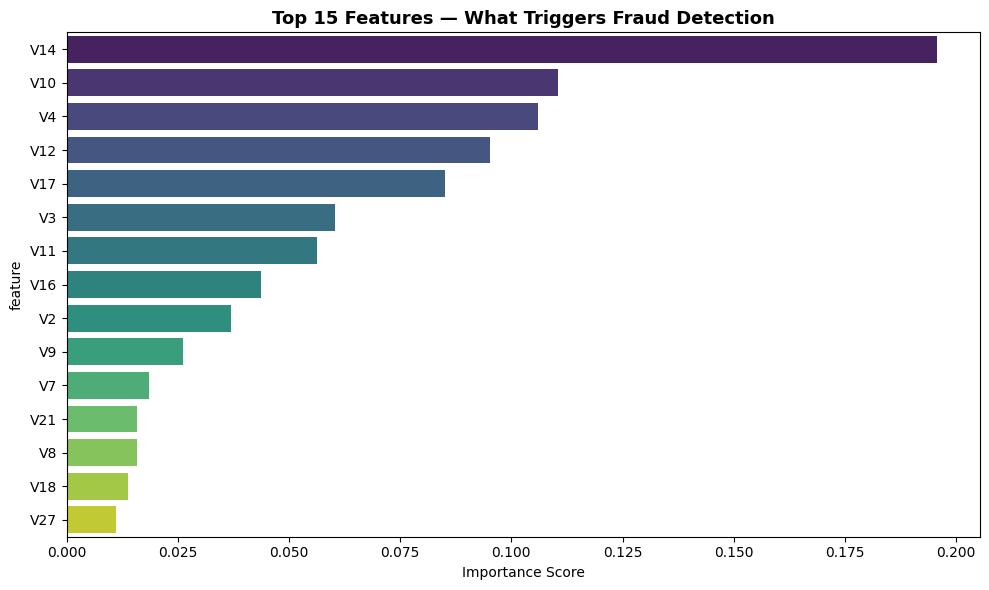

Feature importance chart saved ✅


In [32]:
feature_importance = pd.DataFrame({
    'feature'   : X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance,
            x='importance', y='feature',
            palette='viridis')
plt.title('Top 15 Features — What Triggers Fraud Detection',
          fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../data/feature_importance.png', dpi=150)
plt.show()

print("Feature importance chart saved ✅")

In [12]:
# Save model and scaler so we can reuse them
# without retraining every time
os.makedirs('../models', exist_ok=True)
joblib.dump(model,  '../models/fraud_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

print("fraud_model.pkl saved ✅")
print("scaler.pkl saved ✅")
print(f"\nModel file size: {os.path.getsize('../models/fraud_model.pkl')/1024/1024:.1f} MB")

fraud_model.pkl saved ✅
scaler.pkl saved ✅

Model file size: 0.0 MB
